<a href="https://colab.research.google.com/github/kfleeks/Phishing-Analysis-Using-LLM/blob/main/Copy_of_llm_phishing_analysis_lab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phishing Email Analysis using LLMs

## Introduction

This Jupyter notebook demonstrates how to use Large Language Models (LLMs) to analyze emails for potential phishing attempts. We'll use the Ollama framework to run a local LLM, then create a simple GUI for one-shot email analysis. Finally, we will test our process with a realworld datasets of phishing emails.

## Setup

First, we need to install Ollama and set up our environment. The setup is exactly the same that we did in the the previous collab.

In [ ]:
# Install zstd, a required dependency for Ollama extraction
!sudo apt-get update && sudo apt-get install -y zstd

# Install Ollama
# The provided output for this cell in the notebook was truncated, so we ensure a robust installation attempt.
!curl -fsSL https://ollama.ai/install.sh | sh

import os

# Ollama typically installs to /usr/local/bin. Ensure this is in the PATH
# for the current session and for subprocesses (like asyncio.create_subprocess_exec).
if "/usr/local/bin" not in os.environ["PATH"]:
    os.environ["PATH"] += ":/usr/local/bin"
    print("Added /usr/local/bin to PATH for ollama.")

# Verify ollama is now in the PATH and executable
try:
    ollama_version_output = !ollama --version
    print(f"Ollama installed: {ollama_version_output[0]}")
except Exception as e:
    print(f"Could not verify Ollama installation: {e}")
    print("Please check the output of the install command above for errors.")

# For debugging, print the current PATH to confirm
print(f"Current PATH: {os.environ['PATH']}")

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,821 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (

Next, we'll set up the necessary environment variables and start the Ollama server:

In [ ]:
import os
import asyncio
import threading
import time

# NB: You may need to set these depending and get cuda working depending which backend you are running.
# Set environment variable for NVIDIA library
# Set environment variables for CUDA
os.environ['PATH'] += ':/usr/local/cuda/bin'
# Set LD_LIBRARY_PATH to include both /usr/lib64-nvidia and CUDA lib directories
os.environ['LD_LIBRARY_PATH'] = '/usr/lib64-nvidia:/usr/local/cuda/lib64'

# Helper functions to run Ollama server
async def run_process(cmd, stdout=None, stderr=None):
    print('>>> starting', *cmd)
    process = await asyncio.create_subprocess_exec(
        *cmd,
        stdout=stdout or asyncio.subprocess.PIPE,
        stderr=stderr or asyncio.subprocess.PIPE
    )

    if stdout is None and stderr is None:
        async def pipe(lines):
            async for line in lines:
                print(line.decode().strip())

        await asyncio.gather(
            pipe(process.stdout),
            pipe(process.stderr),
        )
    else:
        await process.wait()

async def start_ollama_serve():
    # Use the absolute path to the ollama executable for robustness
    await run_process(['/usr/local/bin/ollama', 'serve'],
                      stdout=open(os.devnull, 'w'),
                      stderr=open(os.devnull, 'w'))

# Start Ollama server in a separate thread
def run_async_in_thread(loop, coro):
    asyncio.set_event_loop(loop)
    loop.run_until_complete(coro)
    loop.close()

# Create a new event loop that will run in a new thread
new_loop = asyncio.new_event_loop()

# Start ollama serve in a separate thread so the cell won't block execution
thread = threading.Thread(target=run_async_in_thread, args=(new_loop, start_ollama_serve()))
thread.start()

# Wait 5s for ollama to load
time.sleep(5)

>>> starting /usr/local/bin/ollama serve


## Install dependencies

Now, let's install the required Python packages that we will need.


In [ ]:
# We first need to install dependencies
%pip install openai pydantic instructor ipywidgets beautifulsoup4 pandas tqdm chardet matplotlib seaborn wordcloud

## Download the LLM model

You can use another model available in the [ollama library](https://ollama.com/library)

In [ ]:
import os

# Set the MODEL variable
OLLAMA_MODEL = "gemma2:9b-instruct-q4_K_M"

# Run the ollama pull command
!ollama pull {OLLAMA_MODEL}

## Define data models

Let's define our Pydantic models for structuring the phishing analysis results:

In [ ]:
from pydantic import BaseModel, Field
from enum import Enum
from typing import List

class PhishingProbability(str, Enum):
    LOW = "low"
    MEDIUM = "medium"
    HIGH = "high"

class SuspiciousElement(BaseModel):
    element: str
    reason: str

class SimplePhishingAnalysis(BaseModel):
    is_potential_phishing: bool
    phishing_probability: PhishingProbability
    suspicious_elements: List[SuspiciousElement]
    recommended_actions: List[str]
    explanation: str

## Implement email analysis function

Now, let's create a function to analyze emails using our LLM:

In [ ]:
from openai import OpenAI
import instructor


def analyze_email(email_content: str) -> SimplePhishingAnalysis:
    client = instructor.from_openai(
      OpenAI(
          base_url="http://127.0.0.1:11434/v1",
          api_key="ollama",  # required, but unused
      ),
      mode=instructor.Mode.JSON,
  )

    resp = client.chat.completions.create(
        model=OLLAMA_MODEL,
        messages=[
            {
                "role": "system",
                "content": "You are an advanced AI assistant specialized in cybersecurity, particularly in detecting and analyzing phishing attempts in emails. Your task is to analyze the provided email content and metadata to determine if it's a potential phishing attempt. You must provide your analysis in a structured format that matches the model.",
            },
            {
                "role": "user",
                "content": email_content,
            },
        ],
        response_model=SimplePhishingAnalysis,
    )
    return resp

## Test the analysis function

Let's test our analysis function with example emails:

In [ ]:
import json

# Example phishing email
phishing_email = """
From: security@amazonsupport.net
To: john.doe@company.com
Subject: Urgent: Your Amazon Account Has Been Locked

Dear Valued Customer,

We have detected unusual activity on your Amazon account. To prevent unauthorized access, we have temporarily locked your account for your protection.

To unlock your account and restore full access, please click on the link below and verify your information:

https://amaz0n-account-verify.com/unlock-account

If you do not verify your account within 24 hours, it will be permanently disabled.

Thank you for your prompt attention to this matter.

Best regards,
Amazon Security Team

This email was sent by Amazon.com. To ensure delivery to your inbox, please add security@amazonsupport.net to your address book.
"""

analysis = analyze_email(phishing_email)
print(json.dumps(analysis.model_dump(), indent=2))

# Example legitimate email
legitimate_email = """
From: jennifer.smith@company.com
To: team@company.com
Subject: Quarterly Review Meeting - Thursday, 2 PM

Dear Team,

I hope this email finds you well. I'm writing to remind everyone about our upcoming Quarterly Review Meeting scheduled for this Thursday at 2 PM in the main conference room.

Agenda:
1. Q2 Performance Overview
2. Project Updates
3. Q3 Goals and Strategies
4. Open Discussion

Please come prepared with your team's updates and any questions you may have. If you're unable to attend in person, you can join via our usual video conferencing link:
https://company.zoom.us/j/123456789

Don't forget to bring your laptops for the interactive portion of the meeting.

If you have any questions or need to discuss anything before the meeting, feel free to drop by my office or send me an email.

Looking forward to seeing everyone on Thursday!

Best regards,
Jennifer Smith
Head of Operations
Company Inc.
"""

analysis = analyze_email(legitimate_email)
print(json.dumps(analysis.model_dump(), indent=2))

{
  "is_potential_phishing": true,
  "phishing_probability": "high",
  "suspicious_elements": [
    {
      "element": "Sender Address",
      "reason": "The sender address (security@amazonsupport.net) closely resembles a legitimate Amazon address but contains a slight variation which is common in phishing attacks."
    },
    {
      "element": "Subject Line",
      "reason": "The subject line uses alarmist language ('Urgent: Your Amazon Account Has Been Locked') to create a sense of urgency and pressure the recipient to act without thinking."
    },
    {
      "element": "Link in Email Body",
      "reason": "The email contains a link (https://amaz0n-account-verify.com/unlock-account) that does not lead to a legitimate Amazon website. The domain name is a spoofed version of the actual Amazon domain."
    },
    {
      "element": "Time Pressure",
      "reason": "The email sets a strict deadline (24 hours) for the recipient to verify their account, creating further urgency and poten

## Create a GUI for Email Analysis

Finally, let's create a simple GUI for email analysis using IPython widgets. It will take as input only a text box but you can improve it by using a mailbox parser, supporting attachments, ioc extractions...

In [ ]:
from IPython.display import display, HTML
import ipywidgets as widgets

# GUI components
email_input = widgets.Textarea(
    value='',
    placeholder='Paste the email content here...',
    description='Email:',
    disabled=False,
    layout={'width': '100%', 'height': '200px'}
)

analyze_button = widgets.Button(
    description='Analyze Email',
    disabled=False,
    button_style='primary',
    tooltip='Click to analyze the email',
    icon='check'
)

output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        print("Analyzing email...")
        try:
            analysis = analyze_email(email_input.value)
            display(HTML(format_analysis(analysis)))
        except Exception as e:
            print(f"An error occurred: {str(e)}")

analyze_button.on_click(on_button_clicked)

def format_analysis(analysis: SimplePhishingAnalysis) -> str:
    color = "red" if analysis.is_potential_phishing else "green"
    result = f"""
    <h2 style="color: {color};">{'Potential Phishing Detected' if analysis.is_potential_phishing else 'Likely Legitimate Email'}</h2>
    <p><strong>Phishing Probability:</strong> {analysis.phishing_probability.value}</p>
    <h3>Suspicious Elements:</h3>
    <ul>
    """
    for element in analysis.suspicious_elements:
        result += f"<li><strong>{element.element}:</strong> {element.reason}</li>"
    result += "</ul>"
    result += f"""
    <h3>Recommended Actions:</h3>
    <ul>
    """
    for action in analysis.recommended_actions:
        result += f"<li>{action}</li>"
    result += "</ul>"
    result += f"<h3>Explanation:</h3><p>{analysis.explanation}</p>"
    return result

# Display the GUI
display(email_input, analyze_button, output)

Textarea(value='', description='Email:', layout=Layout(height='200px', width='100%'), placeholder='Paste the e…

Button(button_style='primary', description='Analyze Email', icon='check', style=ButtonStyle(), tooltip='Click …

Output()

## Download and process phishing emails

Let's now test our process with realworld phishing emails coming from the [phishing_pot dataset](https://github.com/rf-peixoto/phishing_pot).

First, we'll define some utility functions to download and process the phishing emails.


In [ ]:
# Set the number of emails to process
MAX_EMAILS = 5  # Change this value to process more or fewer emails

In [ ]:
import requests
import zipfile
import io
import os
import email
from bs4 import BeautifulSoup
import chardet
import pandas as pd
from tqdm import tqdm

def download_and_extract_zip(url, extract_to="."):
    print(f"Downloading zip file from {url}...")
    response = requests.get(url)
    print("Download complete. Extracting contents...")
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Extracted contents to {extract_to}")

def detect_encoding(raw_data):
    result = chardet.detect(raw_data)
    return result["encoding"]

def decode_email_body(body, default_charset="utf-8"):
    if isinstance(body, str):
        return body

    if default_charset is None:
        default_charset = "utf-8"

    encodings_to_try = [default_charset, "ascii", "iso-8859-1", "windows-1252"]
    detected_encoding = detect_encoding(body)
    if detected_encoding:
        encodings_to_try.insert(0, detected_encoding)

    for encoding in encodings_to_try:
        try:
            return body.decode(encoding)
        except UnicodeDecodeError:
            continue

    # If all else fails, decode with errors='replace'
    return body.decode(default_charset, errors="replace")

Now, let's define a function to parse individual email files:


In [ ]:
def process_email_file(file_path):
    try:
        with open(file_path, "rb") as file:
            raw_email = file.read()

        msg = email.message_from_bytes(raw_email)

        subject = msg.get("subject", "")
        from_addr = msg.get("from", "")
        to_addr = msg.get("to", "")

        body = ""
        if msg.is_multipart():
            for part in msg.walk():
                content_type = part.get_content_type()
                content_disposition = str(part.get("Content-Disposition"))

                if "attachment" not in content_disposition:
                    payload = part.get_payload(decode=True)
                    if payload:
                        charset = part.get_content_charset() or "utf-8"
                        decoded_payload = decode_email_body(payload, charset)

                        if content_type == "text/plain":
                            body += decoded_payload
                        elif content_type == "text/html":
                            soup = BeautifulSoup(decoded_payload, "html.parser")
                            body += soup.get_text()
        else:
            payload = msg.get_payload(decode=True)
            if payload:
                charset = msg.get_content_charset() or "utf-8"
                decoded_payload = decode_email_body(payload, charset)
                if msg.get_content_type() == "text/plain":
                    body = decoded_payload
                elif msg.get_content_type() == "text/html":
                    soup = BeautifulSoup(decoded_payload, "html.parser")
                    body = soup.get_text()

        return f"Subject: {subject}\nFrom: {from_addr}\nTo: {to_addr}\n\n{body}"
    except Exception as e:
        print(f"Error processing file {file_path}: {str(e)}")
        return None

## Download and process emails

Now, let's download the phishing emails and parse them:

## Analyze emails using LLM

Next, we'll use our LLM-based analysis function to analyze the processed emails:

In [ ]:
import random

print("Starting the phishing email analysis process...")

# Download and extract the phishing emails
url = "https://github.com/rf-peixoto/phishing_pot/archive/refs/heads/main.zip"
download_and_extract_zip(url)

# Set the correct path to the email directory
email_directory = "phishing_pot-main/email"

# Get all .eml files
all_files = []
for root, dirs, files in os.walk(email_directory):
    all_files.extend([os.path.join(root, file) for file in files if file.endswith(".eml")])

# Shuffle the list of files to have different emails choosen between each run
random.shuffle(all_files)

# Process the randomly selected emails
print(f"Processing up to {MAX_EMAILS} randomly selected emails...")
email_data = []
for file_path in tqdm(all_files[:MAX_EMAILS], desc="Processing emails"):
    email_content = process_email_file(file_path)
    if email_content:
        email_data.append(email_content)

print(f"Processed {len(email_data)} emails successfully")

Starting the phishing email analysis process...
Download complete. Extracting contents...
Extracted contents to .
Processing up to 5 randomly selected emails...


Processing emails: 100%|██████████| 5/5 [00:00<00:00,  6.28it/s]

Processed 5 emails successfully


## Summarize and save results

Finally, let's create a summary of the analysis results and save them to a CSV file:

In [ ]:
print("Analyzing emails using LLM...")
results = []
for email_content in tqdm(email_data, desc="Analyzing emails"):
    try:
        analysis = analyze_email(email_content)
        print(json.dumps(analysis.model_dump(), indent=2))
        results.append(analysis)
    except Exception as e:
        print(f"Error analyzing email: {str(e)}")

print(f"Completed analysis of {len(results)} emails")

Analyzing emails using LLM...


Analyzing emails:  20%|██        | 1/5 [00:14<00:59, 14.82s/it]

{
  "is_potential_phishing": false,
  "phishing_probability": "low",
  "suspicious_elements": [],
  "recommended_actions": [
    "Review email sender addresses carefully."
  ],
  "explanation": "While the email content appears to be legitimate internal communication within a company (Pyramid IT Consulting), it is crucial to practice caution with emails containing personal information like employee IDs and laptop details. Always verify such requests through established communication channels or directly contacting the person involved."
}


Analyzing emails:  40%|████      | 2/5 [00:47<01:15, 25.24s/it]

{
  "is_potential_phishing": true,
  "phishing_probability": "high",
  "suspicious_elements": [
    {
      "element": "Subject",
      "reason": "The subject line contains sexually suggestive and nonsensical language, often used to bait users."
    },
    {
      "element": "Sender Email Address",
      "reason": "The sender email address is unusual and uses a generic domain like 'discounts.sa.com'. Phishing emails frequently employ spoofed addresses."
    },
    {
      "element": "Content",
      "reason": "The email contains explicit language related to male sexual enhancement and promotes a product with sensational claims, typical of spam and phishing campaigns."
    },
    {
      "element": "Call to Action",
      "reason": "There is a clear call to action directed at the recipient to 'Discover' or 'click' on something, which tries to mislead users into taking unwanted actions."
    }
  ],
  "recommended_actions": [
    "Do not click any links or open any attachments in this ema

...

{
  "is_potential_phishing": true,
  "phishing_probability": "high",
  "suspicious_elements": [
    {
      "element": "Sender Address",
      "reason": "Email address uses a generic domain (1803nyc.com) and doesn't resemble an official Ripple domain."
    },
    {
      "element": "Urgency and Threat",
      "reason": "The email creates a sense of urgency by mentioning a recent SEC ruling and potential legal/tax complications, pressure Tactics."
    },
    {
      "element": "Suspicious Link",
      "reason": "No legitimate links are provided to verify information or submit the 'Declaration.'  Likely aiming for phishing link."
    }
  ],
  "recommended_actions": [
    "Do not click any links in this email.",
    "Do not reply to this email.",
    "Verify any communication from Ripple through official channels (website, known support contacts)."
  ],
  "explanation": "This email exhibits several red flags consistent with a phishing attempt. The sender address is suspicious, the content

Analyzing emails:  80%|████████  | 4/5 [01:50<00:29, 29.88s/it]

{
  "is_potential_phishing": true,
  "phishing_probability": "high",
  "suspicious_elements": [
    {
      "element": "Sender Address",
      "reason": "The sender address is spoofed and likely not from a legitimate organization."
    },
    {
      "element": "Email Subject",
      "reason": "The subject line (RE: FYI GRANT.) lacks context and could be used to trick users into opening the email."
    },
    {
      "element": "Message Content",
      "reason": "The message content is generic and contains suspicious phrasing like 'Can We Talk' which aims to elicit a response."
    },
    {
      "element": "Repeated Message",
      "reason": "The email appears to be duplicated with minimal changes, suggesting potential phishing automation."
    }
  ],
  "recommended_actions": [
    "Do not click on any links or open any attachments in the email.",
    "Delete the email immediately.",
    "Verify the sender's identity through a trusted channel before responding."
  ],
  "explanation": 

Analyzing emails: 100%|██████████| 5/5 [02:23<00:00, 28.78s/it]

{
  "is_potential_phishing": true,
  "phishing_probability": "high",
  "suspicious_elements": [
    {
      "element": "Greeting",
      "reason": "Generic greeting \"Dear member\" without personalization."
    },
    {
      "element": "Urgency",
      "reason": "Creates a sense of urgency by threatening account blockage and zeroing balance."
    },
    {
      "element": "Unclear Sender",
      "reason": "Sender email address (xebsalabi@gmail.com) is not associated with a known legitimate organization."
    },
    {
      "element": "Grammatical Errors and Formatting",
      "reason": "Contains grammatical errors and inconsistent formatting, suggesting a lack of professionalism."
    },
    {
      "element": "Suspicious Links",
      "reason": "Includes a button labeled \"View\" that likely leads to a malicious website."
    }
  ],
  "recommended_actions": [
    "Do not click on any links in the email.",
    "Delete the email immediately.",
    "Verify the legitimacy of any communic

## Data analysis

We can then analyse and vizualize the data using pandas, seaborn and matplotlib for instance.

Creating summary of results...

Summary of Analysis Results:
Total emails analyzed: 5
Potential phishing emails: 4
Percentage of potential phishing emails: 80.00%


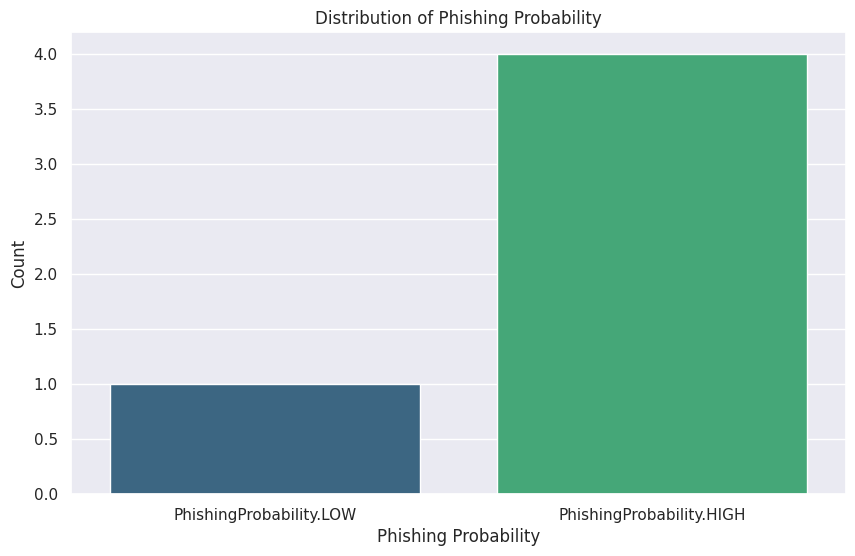

/tmp/ipykernel_28388/66192443.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_elements.values, y=top_elements.index, palette='mako')


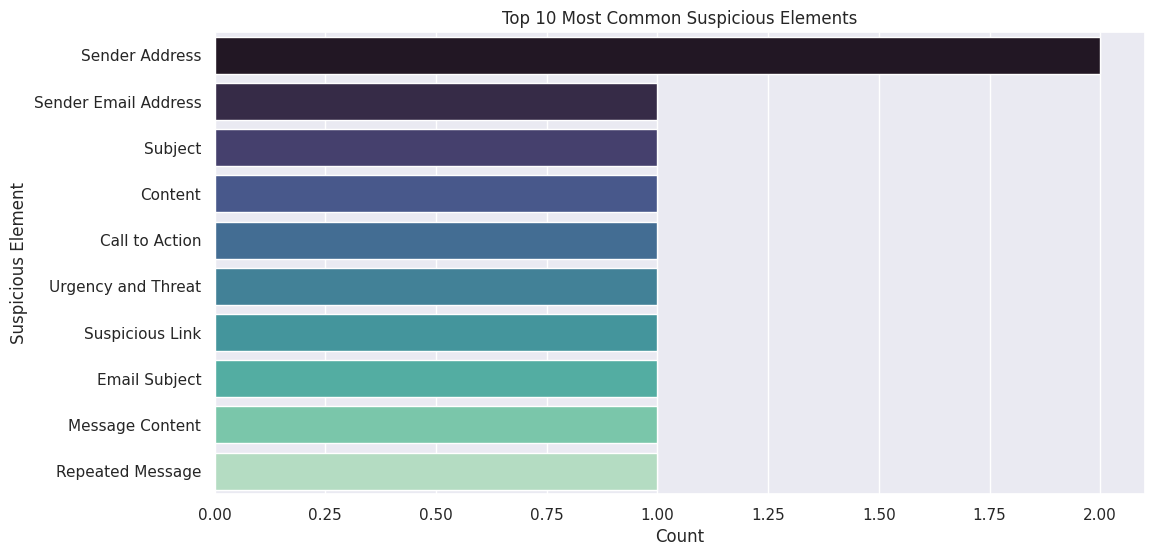

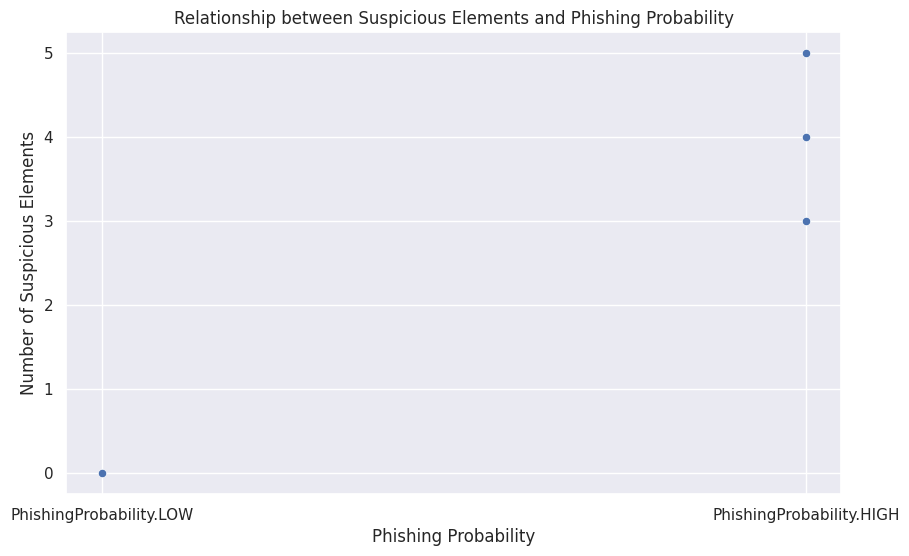

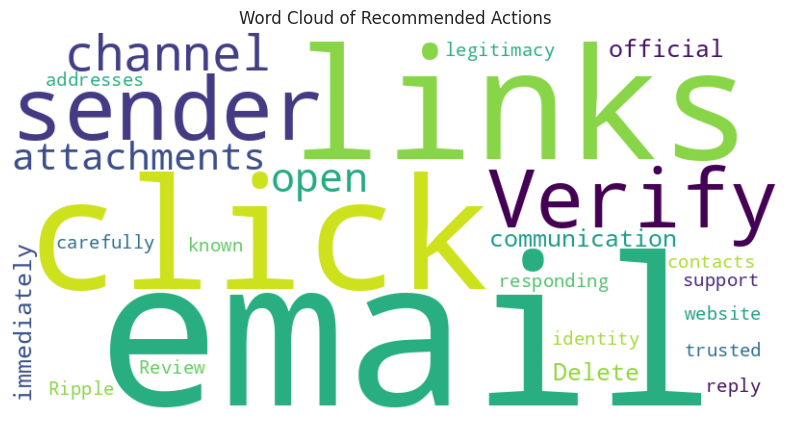


Detailed Information for High-Risk Emails:

Email 2:
Phishing Probability: PhishingProbability.HIGH
Suspicious Elements:
- Subject: The subject line contains sexually suggestive and nonsensical language, often used to bait users.
- Sender Email Address: The sender email address is unusual and uses a generic domain like 'discounts.sa.com'. Phishing emails frequently employ spoofed addresses.
- Content: The email contains explicit language related to male sexual enhancement and promotes a product with sensational claims, typical of spam and phishing campaigns.
- Call to Action: There is a clear call to action directed at the recipient to 'Discover' or 'click' on something, which tries to mislead users into taking unwanted actions.
Recommended Actions:
- Do not click any links or open any attachments in this email.
Explanation: This email shows strong indicators of being a phishing attempt. The subject line, sender address, and content all point towards a scam designed to trick users int

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, HTML
from wordcloud import WordCloud

# Set style for better-looking plots
sns.set_theme()

print("Creating summary of results...")
df_results = pd.DataFrame([result.model_dump() for result in results])

# Display summary statistics
print("\nSummary of Analysis Results:")
print(f"Total emails analyzed: {len(df_results)}")
print(f"Potential phishing emails: {df_results['is_potential_phishing'].sum()}")
print(f"Percentage of potential phishing emails: {df_results['is_potential_phishing'].mean()*100:.2f}%")

# Visualize phishing probability distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='phishing_probability', data=df_results, hue='phishing_probability', legend=False, palette='viridis')
plt.title('Distribution of Phishing Probability')
plt.xlabel('Phishing Probability')
plt.ylabel('Count')
plt.show()

# Analyze and visualize suspicious elements
suspicious_elements = [element['element'] for sublist in df_results["suspicious_elements"] for element in sublist]
df_elements = pd.DataFrame({'element': suspicious_elements})

top_elements = df_elements["element"].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_elements.values, y=top_elements.index, palette='mako')
plt.title('Top 10 Most Common Suspicious Elements')
plt.xlabel('Count')
plt.ylabel('Suspicious Element')
plt.show()


# Correlation between suspicious elements and phishing probability
df_results['suspicious_element_count'] = df_results['suspicious_elements'].apply(len)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='phishing_probability', y='suspicious_element_count', data=df_results)
plt.title('Relationship between Suspicious Elements and Phishing Probability')
plt.xlabel('Phishing Probability')
plt.ylabel('Number of Suspicious Elements')
plt.show()

# Word cloud of recommended actions
all_actions = ' '.join([' '.join(actions) for actions in df_results['recommended_actions']])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_actions)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Recommended Actions')
plt.show()

# Display detailed information for high-risk emails
high_risk_emails = df_results[df_results['phishing_probability'] == PhishingProbability.HIGH.value]
print("\nDetailed Information for High-Risk Emails:")
for idx, email in high_risk_emails.iterrows():
    print(f"\nEmail {idx+1}:")
    print(f"Phishing Probability: {email['phishing_probability']}")
    print("Suspicious Elements:")
    for element in email['suspicious_elements']:
        print(f"- {element['element']}: {element['reason']}")
    print("Recommended Actions:")
    for action in email['recommended_actions']:
        print(f"- {action}")
    print(f"Explanation: {email['explanation']}")
    print("-" * 50)

# Calculate and display overall risk score
risk_score_map = {PhishingProbability.LOW.value: 1, PhishingProbability.MEDIUM.value: 2, PhishingProbability.HIGH.value: 3}
df_results['risk_score'] = df_results['phishing_probability'].map(risk_score_map)
overall_risk_score = df_results['risk_score'].mean()

print(f"\nOverall Risk Score: {overall_risk_score:.2f} out of 3")

# Additional analysis
prob_counts = df_results['phishing_probability'].value_counts()
print("\nPhishing Probability Counts:")
print(prob_counts)

avg_suspicious = df_results['suspicious_element_count'].mean()
print(f"\nAverage number of suspicious elements per email: {avg_suspicious:.2f}")


all_actions = [action for actions in df_results['recommended_actions'] for action in actions]
action_counts = pd.Series(all_actions).value_counts()
print("\nTop 5 most common recommended actions:")
print(action_counts.head())

print("\nSample explanations:")
print(df_results['explanation'].sample(min(3, len(df_results))).to_string())

## Conclusion

This notebook demonstrates how to use LLMs for phishing email analysis. It covers setting up the environment, defining data models, implementing the analysis function, and creating a simple GUI for easy interaction. This approach can be extended and refined for more sophisticated email security applications.
